# Initial Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [5]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC')
print(search_result)


SearchResult containing 47 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 37 TESS Sector 86 2024   SPOC      20   269701147      0.0
 38 TESS Sector 78 2024   SPOC     120   269701147      0.0
 39 TESS Sector 76 2024   SPOC     120   269701147      0

In [6]:
# Use the `.table` attribute to filter and access data
table = search_result.table

# Get missions (sectors) that have 20-second exposures
sectors_with_20s = set(table[table['exptime'] == 20]['mission'])

print(sectors_with_20s)

{'TESS Sector 51', 'TESS Sector 48', 'TESS Sector 49', 'TESS Sector 83', 'TESS Sector 41', 'TESS Sector 79', 'TESS Sector 56', 'TESS Sector 73', 'TESS Sector 82', 'TESS Sector 78', 'TESS Sector 86', 'TESS Sector 55', 'TESS Sector 75', 'TESS Sector 52', 'TESS Sector 59', 'TESS Sector 76', 'TESS Sector 77', 'TESS Sector 60', 'TESS Sector 85'}


In [7]:
# Now build filtered list, preferring 20s over 120s
filtered_results = []

for mission in set(table['mission']):
    if mission in sectors_with_20s:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 20)]
    else:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 120)]
    if len(result) > 0:
        filtered_results.append(result[0])
# print(filtered_results)

In [8]:
# Create final SearchResult
from lightkurve.search import SearchResult
from astropy.table import vstack
# Extract the table rows from each mini SearchResult
filtered_tables = [sr.table[0] for sr in filtered_results]

# Stack them into one Astropy Table
stacked_table = vstack(filtered_tables)

# Create final SearchResult
filtered_search = SearchResult(stacked_table)

# Download all matching light curves
lc_collection = filtered_search.download_all()


# lc_collection = search_result.download_all()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [9]:
### mask transits out before normalizing and removing outliers 
# if mask_transits == True:
#     # Store detrended, masked individual light curves
#     detrended_lcs = []
#     ### mask transit times before flattening
#     transit_times1_120 = [1715.354746482542, 1733.115369534969, 1741.996345354458, 1759.758819060445, 
#                           1786.3986654179103, 1795.2831459740814, 1804.1592033060992, 1813.0392831314516, 
#                           1821.9180145080772, 1830.8017387539828, 1839.6804898115759, 1875.2014897815563, 
#                           1892.9628647808674, 1901.843275813667, 1910.7223686858317, 1919.6014862983075, 
#                           1964.003725469874, 1972.8840175983191, 1981.7646658445788, 1990.644612114476, 
#                           1999.524639406961, 2008.4052942751948, 2425.7826938851645, 2434.6627506979466, 
#                           2443.542455620913, 2612.2662638526494, 2621.150658695988, 2630.0280519404414, 
#                           2647.789592040927, 2656.669673413452, 2701.07335988083, 2718.832273895279, 
#                           2727.7109563935223, 2736.5923796134493, 2798.753896465541, 2807.6346091497285, 
#                           2816.5149086624456, 2825.396246422208, 2834.2782280828546, 2843.1567921247233, 
#                           2852.0360595551683, 2914.195996437057, 2923.0777268631805, 2931.9570406091407, 
#                           2940.8440758911756, 2949.7211045589625, 2958.601791561051, 3296.0512996511125, 
#                           3340.4540517320133, 3349.3337618516202, 3358.2141007437344, 3367.096528308062, 
#                           3375.976348274385, 3384.855758190766, 3393.73881858342, 3402.6170508730675, 
#                           3420.37372878859, 3438.1405935487614, 3447.019189674554, 3455.898868469713, 
#                           3464.7799101830874, 3473.6618975064807, 3535.8221842448133, 3544.6994958429154, 
#                           3553.5818340529354, 3562.4634851892574, 3571.3440690158545, 3580.222328354312, 
#                           3615.745064261839, 3660.1447093186034]
#     transit_times2_120 = [1726.0543073746499, 1754.634043965897, 1783.2115328271677, 1811.799709252357, 
#                           1840.375325305024, 1897.535580205685, 1926.1164468441034, 2440.5464000264496, 
#                           2612.028543417274, 2697.771827053584, 2726.351987285226, 2812.0954555257877, 
#                           2840.6723275065156, 2926.4215475832184, 3297.9726631034496, 3355.130554203686, 
#                           3383.7103874786258, 3440.8754011789956, 3555.19503141751, 3583.7721295971896, 
#                           3640.9330744268664]
#     transit_times3_120 = [1743.5522822268827, 1781.9030676559116, 1820.2655396847936, 1896.96100510817, 
#                           1973.6640664787449, 2433.9156496340456, 2664.024879204517, 2702.3548744476616, 
#                           2740.7164183232103, 2817.4104839147385, 2932.462260903496, 3354.3029929461736, 
#                           3392.6619207076765, 3546.072794556178, 3622.7679361489895, 3661.1260225588803]
#     # transit_times1_20 = [2425.781671135145, 2434.6624703174352, 2443.5423796109203, 2612.2684481713577, 
#     #                      2621.1510454117415, 2630.0275398575673, 2647.7900538979006, 2656.669726531292, 
#     #                      2701.0725414166154, 2718.8323542612056, 2727.710907504246, 2736.5922493638554, 
#     #                      2798.7545420305955, 2807.6356634491485, 2816.514655391101, 2825.395530143617, 
#     #                      2834.277484692579, 2843.156974635499, 2852.0384484248025, 2914.197384150204, 
#     #                      2923.0778820870382, 2931.9571207364143, 2940.839689041113, 2958.6015109188284, 
#     #                      3296.051121211378, 3340.4532059302223, 3349.3343529494396, 3358.2128462226856, 
#     #                      3367.10014952418, 3375.9753461665846, 3384.8550146672706, 3393.7383879034232, 
#     #                      3420.3769893786307, 3438.136540591031, 3447.0192700680527, 3455.8988195587076, 
#     #                      3464.7791668472623, 3473.662182303581, 3535.821570188835, 3544.700577259685, 
#     #                      3553.582118804313, 3562.4637427893786, 3571.3442515432093, 3580.222381562287, 
#     #                      3615.7453217433413, 3633.5065285943206, 3660.1447894582507]
#     # transit_times2_20 = [2440.5453772579517, 2612.0257498217884, 2640.607360037848, 2697.772009576271, 
#     #                      2726.3527350293425, 2812.097640098747, 2840.6726872691265, 2926.4182639328533, 
#     #                      3297.970203178181, 3355.1306343302267, 3383.7110057186396, 3440.8761217520487, 
#     #                      3555.194805258147, 3583.7676407579665, 3612.3498560606936, 3640.9332567617016]
#     # transit_times3_20 = [2433.9165746177628, 2664.0253139879796, 2702.3527963863708, 2740.71821502839, 
#     #                      2817.4108437379555, 2932.462313935031, 3354.303508928905, 3392.6595088877752, 
#     #                      3546.0728478211595, 3622.7703249199426, 3661.1276146501823]

    
#     T14_1= 2.939 * 0.0416667 
#     T14_2= 4.162 * 0.0416667 
#     T14_3= 5.36 * 0.0416667
    
#     masked_lc = lc_collection.stitch()

#     times = masked_lc.time.value

#     ### Initialize a mask with all False values (i.e., include all data points initially)
#     mask = np.zeros_like(times, dtype=bool)

#     ### Iterate through each transit time and update the mask
#     for transit_time in transit_times1_120:
#         mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))
#     # for transit_time in transit_times1_20:
#     #     mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))

#     for transit_time in transit_times2_120:
#         mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))
#     # for transit_time in transit_times2_20:
#     #     mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))

#     for transit_time in transit_times3_120:
#         mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))
#     # for transit_time in transit_times3_20:
#     #     mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))

#     ### Flatten the masked light curve
#     masked_lc = masked_lc.normalize().flatten(window_length=2901, mask=mask).remove_outliers()
#     combined_lc = masked_lc
# else:
#     ### flatten unmasked lightcurve 
#     lc = lc_collection.stitch()
#     combined_lc = lc.flatten(window_length=2901).remove_outliers()

# # combined_lc.plot()
# # plt.show()

In [10]:
from lightkurve import LightCurveCollection
import numpy as np

transit_times1_120 = [1715.354746482542, 1733.115369534969, 1741.996345354458, 1759.758819060445, 
                          1786.3986654179103, 1795.2831459740814, 1804.1592033060992, 1813.0392831314516, 
                          1821.9180145080772, 1830.8017387539828, 1839.6804898115759, 1875.2014897815563, 
                          1892.9628647808674, 1901.843275813667, 1910.7223686858317, 1919.6014862983075, 
                          1964.003725469874, 1972.8840175983191, 1981.7646658445788, 1990.644612114476, 
                          1999.524639406961, 2008.4052942751948, 2425.7826938851645, 2434.6627506979466, 
                          2443.542455620913, 2612.2662638526494, 2621.150658695988, 2630.0280519404414, 
                          2647.789592040927, 2656.669673413452, 2701.07335988083, 2718.832273895279, 
                          2727.7109563935223, 2736.5923796134493, 2798.753896465541, 2807.6346091497285, 
                          2816.5149086624456, 2825.396246422208, 2834.2782280828546, 2843.1567921247233, 
                          2852.0360595551683, 2914.195996437057, 2923.0777268631805, 2931.9570406091407, 
                          2940.8440758911756, 2949.7211045589625, 2958.601791561051, 3296.0512996511125, 
                          3340.4540517320133, 3349.3337618516202, 3358.2141007437344, 3367.096528308062, 
                          3375.976348274385, 3384.855758190766, 3393.73881858342, 3402.6170508730675, 
                          3420.37372878859, 3438.1405935487614, 3447.019189674554, 3455.898868469713, 
                          3464.7799101830874, 3473.6618975064807, 3535.8221842448133, 3544.6994958429154, 
                          3553.5818340529354, 3562.4634851892574, 3571.3440690158545, 3580.222328354312, 
                          3615.745064261839, 3660.1447093186034]
transit_times2_120 = [1726.0543073746499, 1754.634043965897, 1783.2115328271677, 1811.799709252357, 
                          1840.375325305024, 1897.535580205685, 1926.1164468441034, 2440.5464000264496, 
                          2612.028543417274, 2697.771827053584, 2726.351987285226, 2812.0954555257877, 
                          2840.6723275065156, 2926.4215475832184, 3297.9726631034496, 3355.130554203686, 
                          3383.7103874786258, 3440.8754011789956, 3555.19503141751, 3583.7721295971896, 
                          3640.9330744268664]
transit_times3_120 = [1743.5522822268827, 1781.9030676559116, 1820.2655396847936, 1896.96100510817, 
                          1973.6640664787449, 2433.9156496340456, 2664.024879204517, 2702.3548744476616, 
                          2740.7164183232103, 2817.4104839147385, 2932.462260903496, 3354.3029929461736, 
                          3392.6619207076765, 3546.072794556178, 3622.7679361489895, 3661.1260225588803]



transit_times1_120 = [1715.38944376, 1733.15078837, 1742.0300416,  1759.78984595, 1768.67178277,
                      1786.43280369, 1795.31050246, 1804.19095166, 1813.07136515, 1821.95176484,
                      1830.83076354, 1839.71251761, 1875.2311819,  1892.99194378, 1901.87235482,
                      1910.75139352, 1919.6318458,  1964.03452717, 1972.91376407, 1981.79441236,
                      1990.67230238, 1999.55438592, 2008.43231724, 2425.79790193, 2434.67770012,
                      2443.55794308, 2612.27944255, 2621.15960192, 2630.0397667,  2647.79994506,
                      2656.67995136, 2701.08043055, 2710.00204277, 2718.84057706, 2727.72079863,
                      2736.60080582, 2798.76153233, 2807.64155056, 2816.52154351, 2825.40175094,
                      2834.28170348, 2843.16186077, 2852.04199989, 2914.20260399, 2923.08253678,
                      2931.96267424, 2940.84257321, 2949.72062379, 2958.60306042, 3296.04633103,
                      3340.44674742, 3349.32689343, 3358.20705504, 3367.08701766, 3375.9672193,
                      3384.84722147, 3393.72725802, 3402.60730882, 3420.36752782, 3438.12784854,
                      3447.00780649, 3455.88802332, 3464.76803693, 3473.64804938, 3535.80877194,
                      3544.68878001, 3553.56898689, 3562.44894255, 3571.32911764, 3580.20924966,
                      3615.72952053, 3633.48972638, 3642.37430564, 3660.12998926]
transit_times2_120 = [1726.07571219, 1754.65511506, 1783.23282912, 1811.81444057, 1840.39305961,
                      1897.55298087, 1926.13318022, 2440.5671511,  2612.04495659, 2640.62479627,
                      2697.78410709, 2726.36360003, 2812.10273058, 2840.68221763, 2926.42135249,
                      2955.05822891, 3297.95694203, 3355.11614071, 3383.69584474, 3440.8551862,
                      3469.43477825, 3555.1738697,  3583.75371223, 3612.33302674, 3640.91275712]
transit_times3_120 = [1743.60505174, 1781.95645021, 1820.30596336, 1897.00715535, 1973.70543708,
                      2433.90801186, 2625.65882173, 2664.00907691, 2702.35914648, 2740.70921642,
                      2817.40951948, 2932.45965505, 3354.31129592, 3392.66152132, 3469.29195181,
                      3546.0619494,  3584.34445526, 3622.76232735, 3661.1123786]


T14_1 = 2.939 * 0.0416667
T14_2 = 4.162 * 0.0416667
T14_3 = 5.36 * 0.0416667

if mask_transits == True:
    # Store detrended, masked individual light curves
    detrended_lcs = []

    for lc in lc_collection:
        lc_clean = lc.remove_nans()
        times = lc_clean.time.value
        mask = np.zeros_like(times, dtype=bool)

        # Apply transit time masks
        for transit_time in transit_times1_120:
            mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))
        for transit_time in transit_times2_120:
            mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))
        for transit_time in transit_times3_120:
            mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))

        # Choose flattening window size based on cadence
        if lc.meta["EXPOSURE"] < 60:
            window = 1001
        else:
            window = 301

        window = 1901

        try:
            lc_flat = lc_clean.normalize().flatten(window_length=window, mask=mask).remove_outliers()
            detrended_lcs.append(lc_flat)
        except Exception as e:
            print(f"Skipping one LC due to error: {e}")

    # Stitch all masked/detrended LCs
    combined_lc = LightCurveCollection(detrended_lcs).stitch()

else:
    # Detrend individually without transit masking
    detrended_lcs = []

    for lc in lc_collection:
        lc_clean = lc.remove_nans()

        # Choose flattening window based on cadence
        if lc.meta["EXPOSURE"] < 60:
            window = 1001
        else:
            window = 301

        try:
            lc_flat = lc_clean.normalize().flatten(window_length=window).remove_outliers()
            detrended_lcs.append(lc_flat)
        except Exception as e:
            print(f"Skipping one LC due to error: {e}")

# Optional plot
# combined_lc.plot()
# plt.show()
# Stitch all flattened LCs
combined_lc = LightCurveCollection(detrended_lcs).stitch()


In [11]:
# clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [12]:
# # Normalize, flatten, and remove outliers
# processed_lcs = [
#     lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
#     for lc in clean_lcs
# ]

In [13]:
# # Stitch into one combined light curve
# combined_lc = processed_lcs[0]
# for lc in processed_lcs[1:]:
#     combined_lc = combined_lc.append(lc)



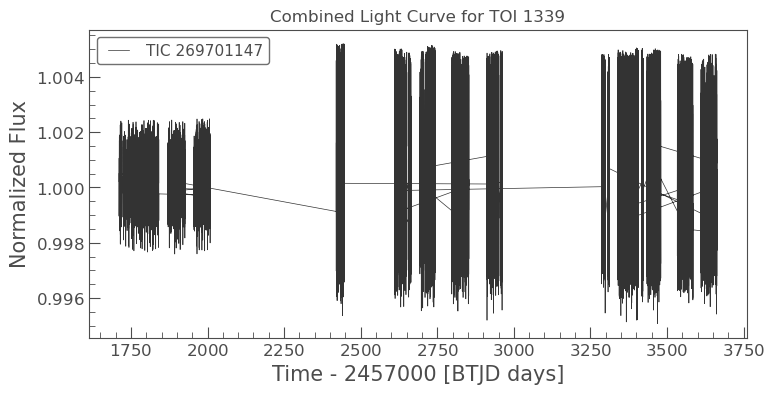

In [14]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [15]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1764.68568085 1764.68706974 1764.68845862 ... 3367.48168743 3367.48191891
 3367.48215039]
[1.00084211 0.99995643 1.00031091 ... 1.00135447 0.99832535 1.00054701]


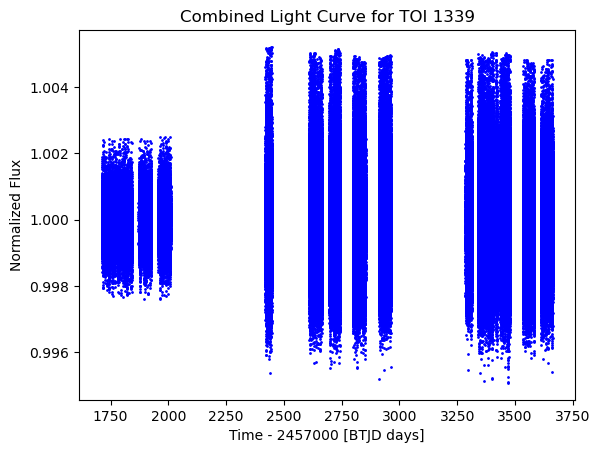

In [16]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 147250 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


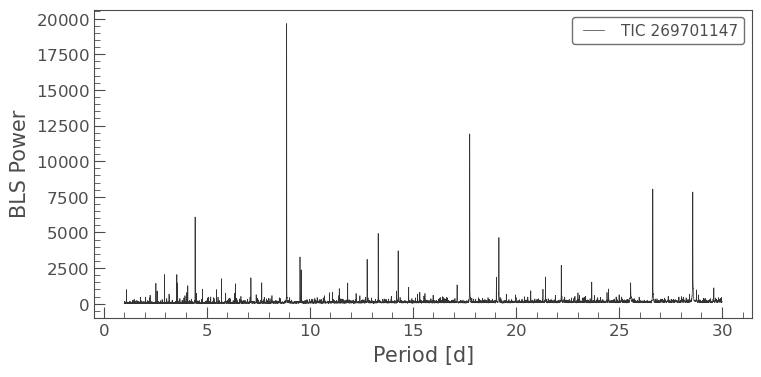

In [17]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [18]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 1715.39077 days
Best candidate dur: 0.10000 days


In [19]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

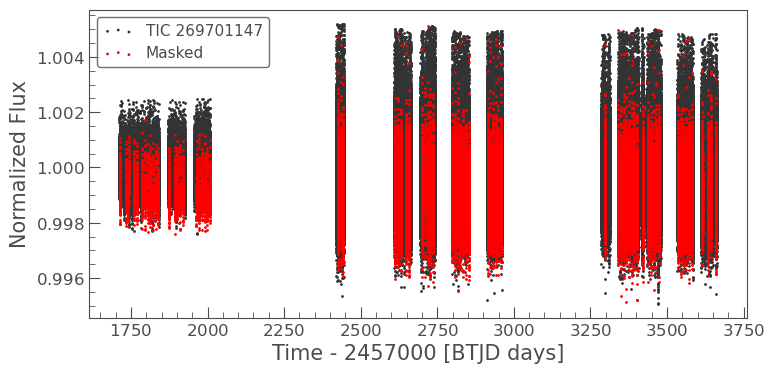

In [20]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [21]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


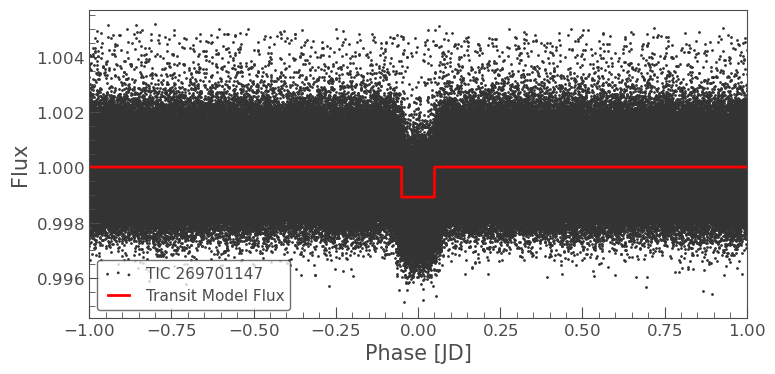

In [22]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


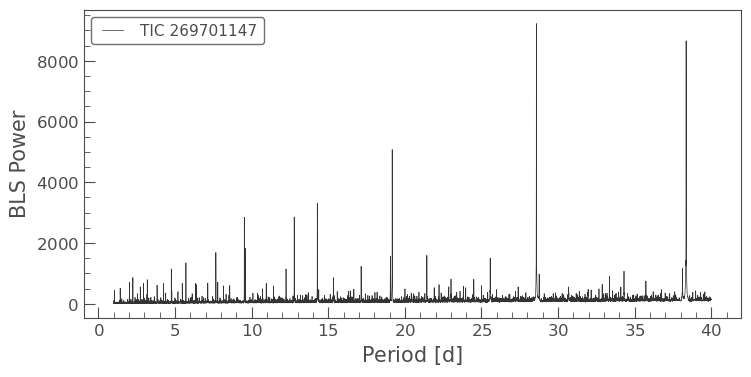

In [23]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [24]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 1726.07077 days


In [25]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [26]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

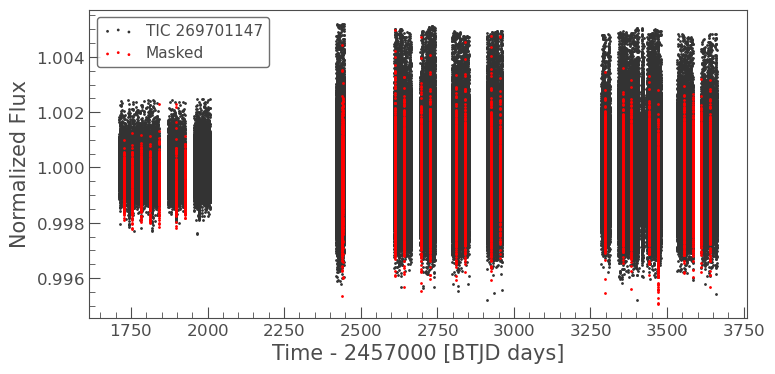

In [27]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [28]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

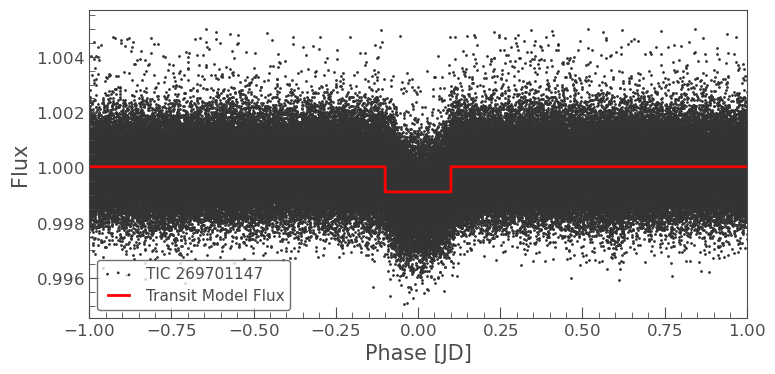

In [29]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


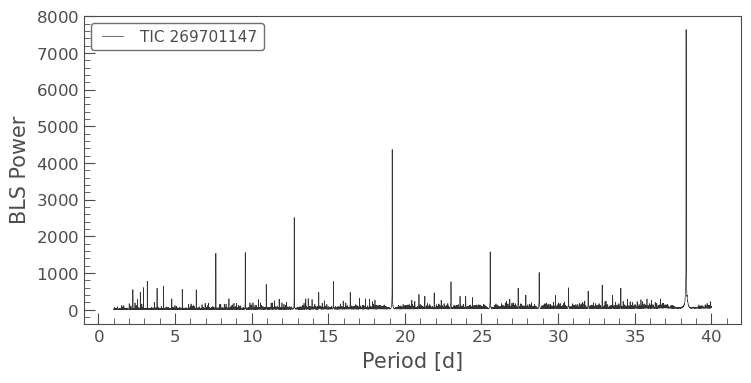

In [30]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [31]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 1743.60577 days


In [32]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*2.5)

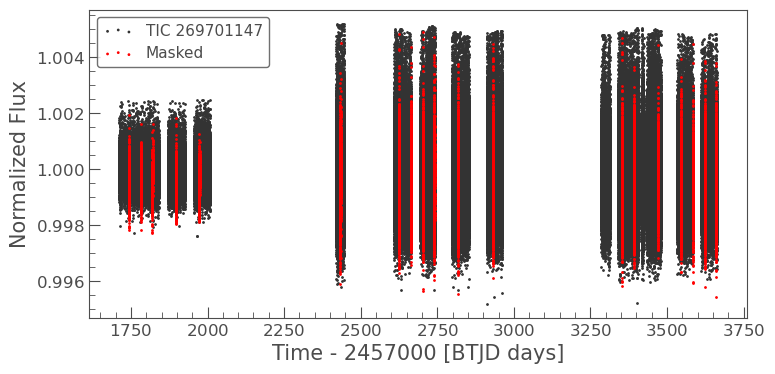

In [33]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [34]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

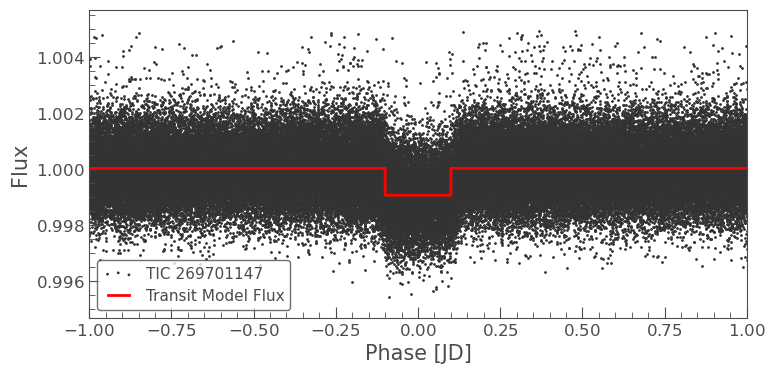

In [35]:
ax = masked_lc_2.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

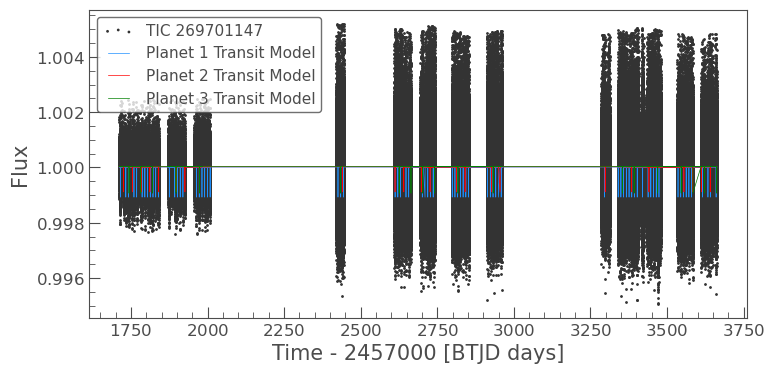

In [36]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [37]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = np.sort(planet_1_model.time.value[peaks_1])
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1715.38944376 1733.15078837 1742.0300416  1759.78984595 1768.67178277
 1786.43280369 1795.31050246 1804.19095166 1813.07136515 1821.95176484
 1830.83076354 1839.71251761 1875.2311819  1892.99194378 1901.87235482
 1910.75139352 1919.6318458  1964.03452717 1972.91376407 1981.79441236
 1990.67230238 1999.55438592 2008.43231724 2425.79790193 2434.67770012
 2443.55794308 2612.27944255 2621.15960192 2630.0397667  2647.79994506
 2656.67995136 2701.08043055 2710.00204277 2718.84057706 2727.72079863
 2736.60080582 2798.76153233 2807.64155056 2816.52154351 2825.40175094
 2834.28170348 2843.16186077 2852.04199989 2914.20260399 2923.08253678
 2931.96267424 2940.84257321 2949.72062379 2958.60306042 3296.04633103
 3340.44674742 3349.32689343 3358.20705504 3367.08701766 3375.9672193
 3384.84722147 3393.72725802 3402.60730882 3420.36752782 3438.12784854
 3447.00780649 3455.88802332 3464.76803693 3473.64804938 3535.80877194
 3544.68878001 3553.56898689 3562.44894

In [38]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1726.07015657 1754.64955949 1783.22866248 1811.8088851  1840.38750416
 1897.54742539 1926.1276247  2440.56205842 2612.04032706 2640.61970375
 2697.77901446 2726.35873884 2812.09763792 2840.67758798 2926.41626
 2955.06795092 3297.95184954 3355.11127969 3383.6907522  3440.85009356
 3469.42968557 3555.16877703 3583.74861961 3612.32816569 3640.90766462]


In [39]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = np.sort(planet_3_model.time.value[peaks_3])
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[1743.60505174 1781.95645021 1820.30596336 1897.00715535 1973.70543708
 2433.90801186 2625.65882173 2664.00907691 2702.35914648 2740.70921642
 2817.40951948 2932.45965505 3354.31129592 3392.66152132 3469.27065516
 3546.0619494  3584.34445526 3622.76232735 3661.1123786 ]


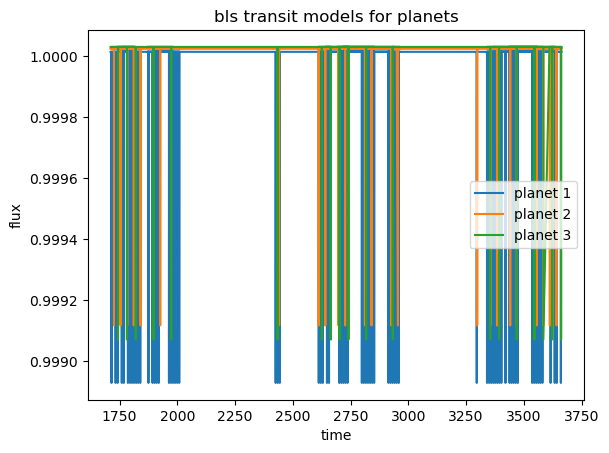

In [40]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [41]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [42]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [43]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        # ### fit parabola to the chisq
        # p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        # ### Extract the coefficients   y = ax^2 + bx + c
        # a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        # ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        # tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        # ### Calculate the minimum chi-squared value
        # chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        # tc_chi_parabola[j] = tc_best_fit
    
        # ### Calculate the parabola best fit 
        # p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        # ### calculate ttv from parabola fit 
        # ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)

        # errors = np.array(errors)

        # ### avg the errors
        # sig = np.sqrt(errors[0]**2 + errors[1]**2)
        # err_tc_chi.append(sig)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv, errors

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [45]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Sort by phase
    sort_idx = np.argsort(folded_phase)
    folded_phase = folded_phase[sort_idx]
    folded_flux = folded_flux[sort_idx]

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [46]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


## Planet 1

In [47]:
### Planet params (from exoplanet archive Gilbert et al 2023)
# planet b
per_1=  8.8803232 #8.8803256
rp_1= 0.0333265970068500 #0.03319
b_1=  0.522936735232103 #0.610
T14_1= 3.06623299086887 * 0.0416667  #2.939 * 0.0416667  # convert to days from hours 


In [48]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [49]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []
err_tc_chi = []

In [50]:
tc_chi_1, ttv_1, tc_err1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [51]:
print(tc_chi_1)

[1715.3549092  1733.11558647 1741.99617437 1759.75864806 1768.63758188
 1786.3986028  1795.28297492 1804.1594201  1813.04317026 1821.91789761
 1830.80190132 1839.68065239 1875.20165235 1892.96274789 1901.84315893
 1910.72219763 1919.60164891 1964.00366294 1972.88390085 1981.7648828
 1990.64477483 1999.5245227  2008.40545702 2425.7813854  2434.66251826
 2443.54276122 2612.26826469 2621.15109341 2630.02758785 2647.79010188
 2656.66944084 2701.07258937 2709.95149218 2718.83240221 2727.71128911
 2736.5922973  2798.75435848 2807.63571139 2816.51470333 2825.39591176
 2834.27786631 2843.15668893 2852.03782905 2914.19776581 2923.07769861
 2931.9575024  2940.83973704 2949.72012329 2958.60155892 3296.05083554
 3340.45425494 3349.33440094 3358.21289422 3367.09919651 3375.97472681
 3384.85472898 3393.73810221 3402.61748567 3420.37703733 3438.13702439
 3447.01865068 3455.89853383 3464.77921478 3473.66223024 3535.82261913
 3544.7006252  3553.58250042 3562.46345707 3571.34463316 3580.22242952
 3615.7

In [52]:
### after inspection of single transits
values_to_remove_1 = [2709.95157559]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []
tc_err_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])
        tc_err_1_cleaned.append(tc_err1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
tc_err1 = tc_err_1_cleaned
print("Modified List (after removal):", tc_chi_1)
# print(tc_err1)


Modified List (after removal): [1715.3549092017722, 1733.115586473646, 1741.9961743737624, 1759.758648059144, 1768.6375818756435, 1786.3986027951555, 1795.2829749153886, 1804.1594200996817, 1813.0431702642181, 1821.9178976126339, 1830.8019013226365, 1839.680652386748, 1875.2016523497389, 1892.9627478939042, 1901.8431589320448, 1910.7221976307305, 1919.601648913385, 1964.0036629432025, 1972.8839008536088, 1981.7648828028748, 1990.6447748325165, 1999.5245227031153, 2008.4054570200103, 2425.7813854023902, 2434.662518257186, 2443.5427612163653, 2612.2682646935673, 2621.1510934061903, 2630.027587848815, 2647.790101879494, 2656.66944084259, 2701.072589367608, 2718.832402209758, 2727.711289109938, 2736.592297300766, 2798.754358484076, 2807.6357113864506, 2816.51470333335, 2825.395911761419, 2834.277866309215, 2843.1566889250516, 2852.0378290502304, 2914.1977658129335, 2923.0776986079936, 2931.9575024020814, 2940.8397370431567, 2949.7201232861007, 2958.6015589186595, 3296.050835541113, 3340.45

In [53]:
tc_err_1 = []
for i in range(len(tc_err1)):
    if len(tc_err1[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
        tc_err_1.append(sig)
    else:
        print(f"Unexpected format in tc_err1[{i}]: {tc_err1[i]}, {tc_chi_1[i]}")

# print(tc_err_1)

In [54]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

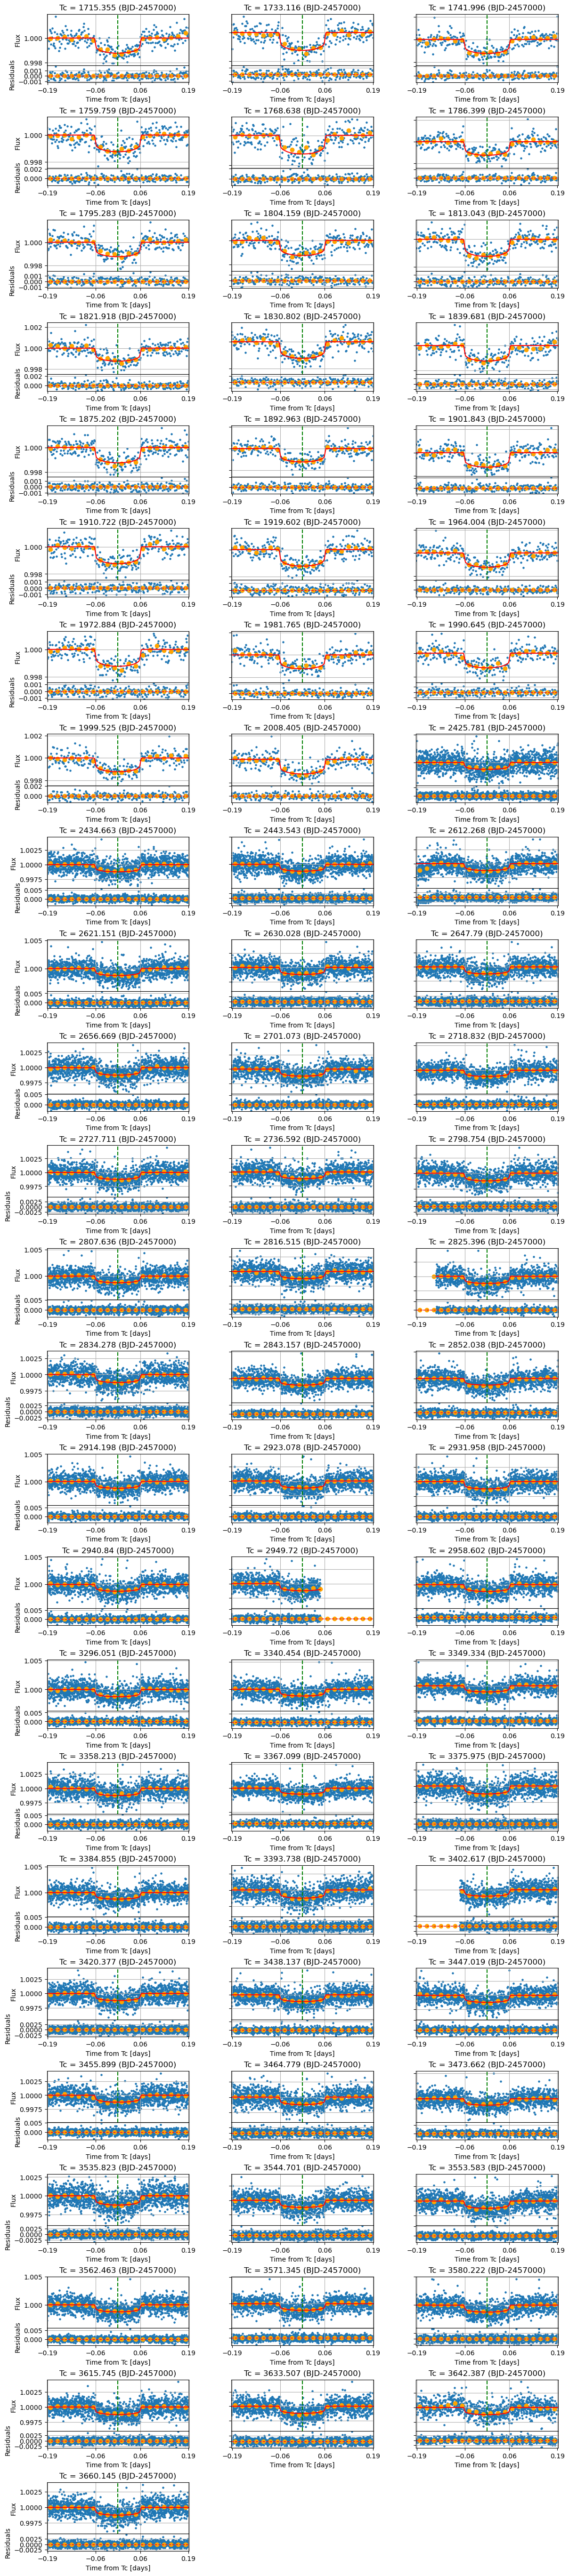

In [55]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

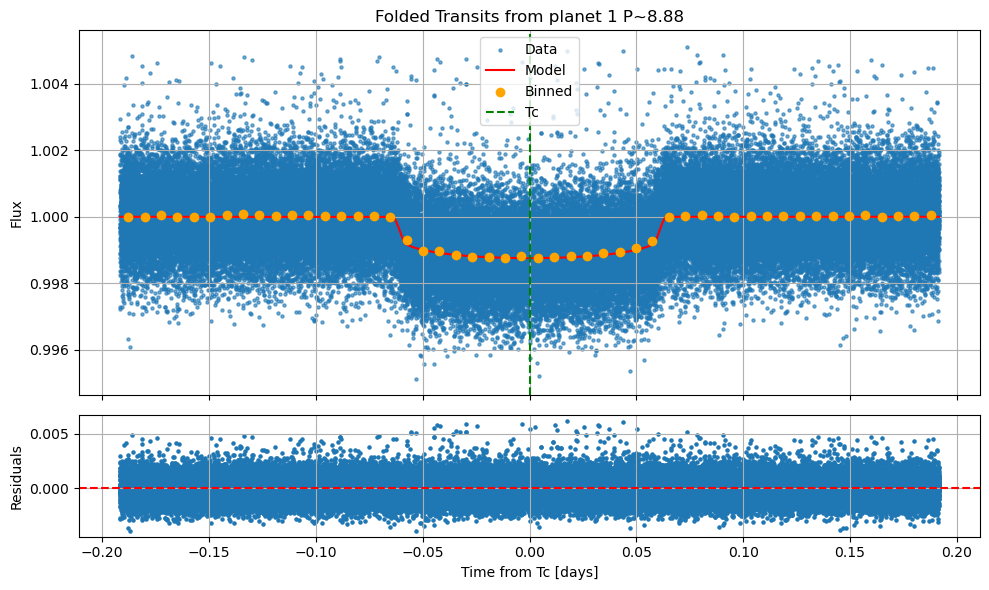

In [56]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [57]:
### Planet params (from barros et al 2022)
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [58]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [59]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []
err_tc_chi = []

In [60]:
tc_chi_2, ttv_2, tc_err2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [61]:
print(tc_chi_2)

[1726.05497471 1754.63404397 1783.21147862 1811.79970925 1840.37532531
 1897.53491287 1926.11611318 2440.54520822 2612.0281482  2640.60685756
 2697.77150694 2726.35289967 2812.09680375 2840.67308347 2926.41909617
 2954.99871496 3297.97103541 3355.12979823 3383.71060541 3440.87662011
 3469.41650571 3555.19563725 3583.77180949 3612.34968722 3640.93152183]


In [62]:
### after inspection of single transits
values_to_remove_2 = [2954.99879838, 3469.42643231]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []
tc_err_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])
        tc_err_2_cleaned.append(tc_err2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
tc_err2 = tc_err_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [1726.0549747091843, 1754.634043965897, 1783.2114786183108, 1811.799709252357, 1840.375325305024, 1897.5349128711505, 1926.1161131768363, 2440.545208221896, 2612.0281482030264, 2640.606857555593, 2697.7715069437895, 2726.3528996657087, 2812.096803754485, 2840.6730834688888, 2926.419096174104, 3297.971035411013, 3355.129798226692, 3383.7106054063725, 3440.8766201062163, 3555.1956372484415, 3583.7718094864576, 3612.3496872240244, 3640.9315218292377]


In [63]:
tc_err_2 = []
for i in range(len(tc_err2)):
    if len(tc_err2[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
        tc_err_2.append(sig)
    else:
        print(f"Unexpected format in tc_err2[{i}]: {tc_err2[i]}, {tc_chi_2[i]}")

# print(tc_err_2)

In [64]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

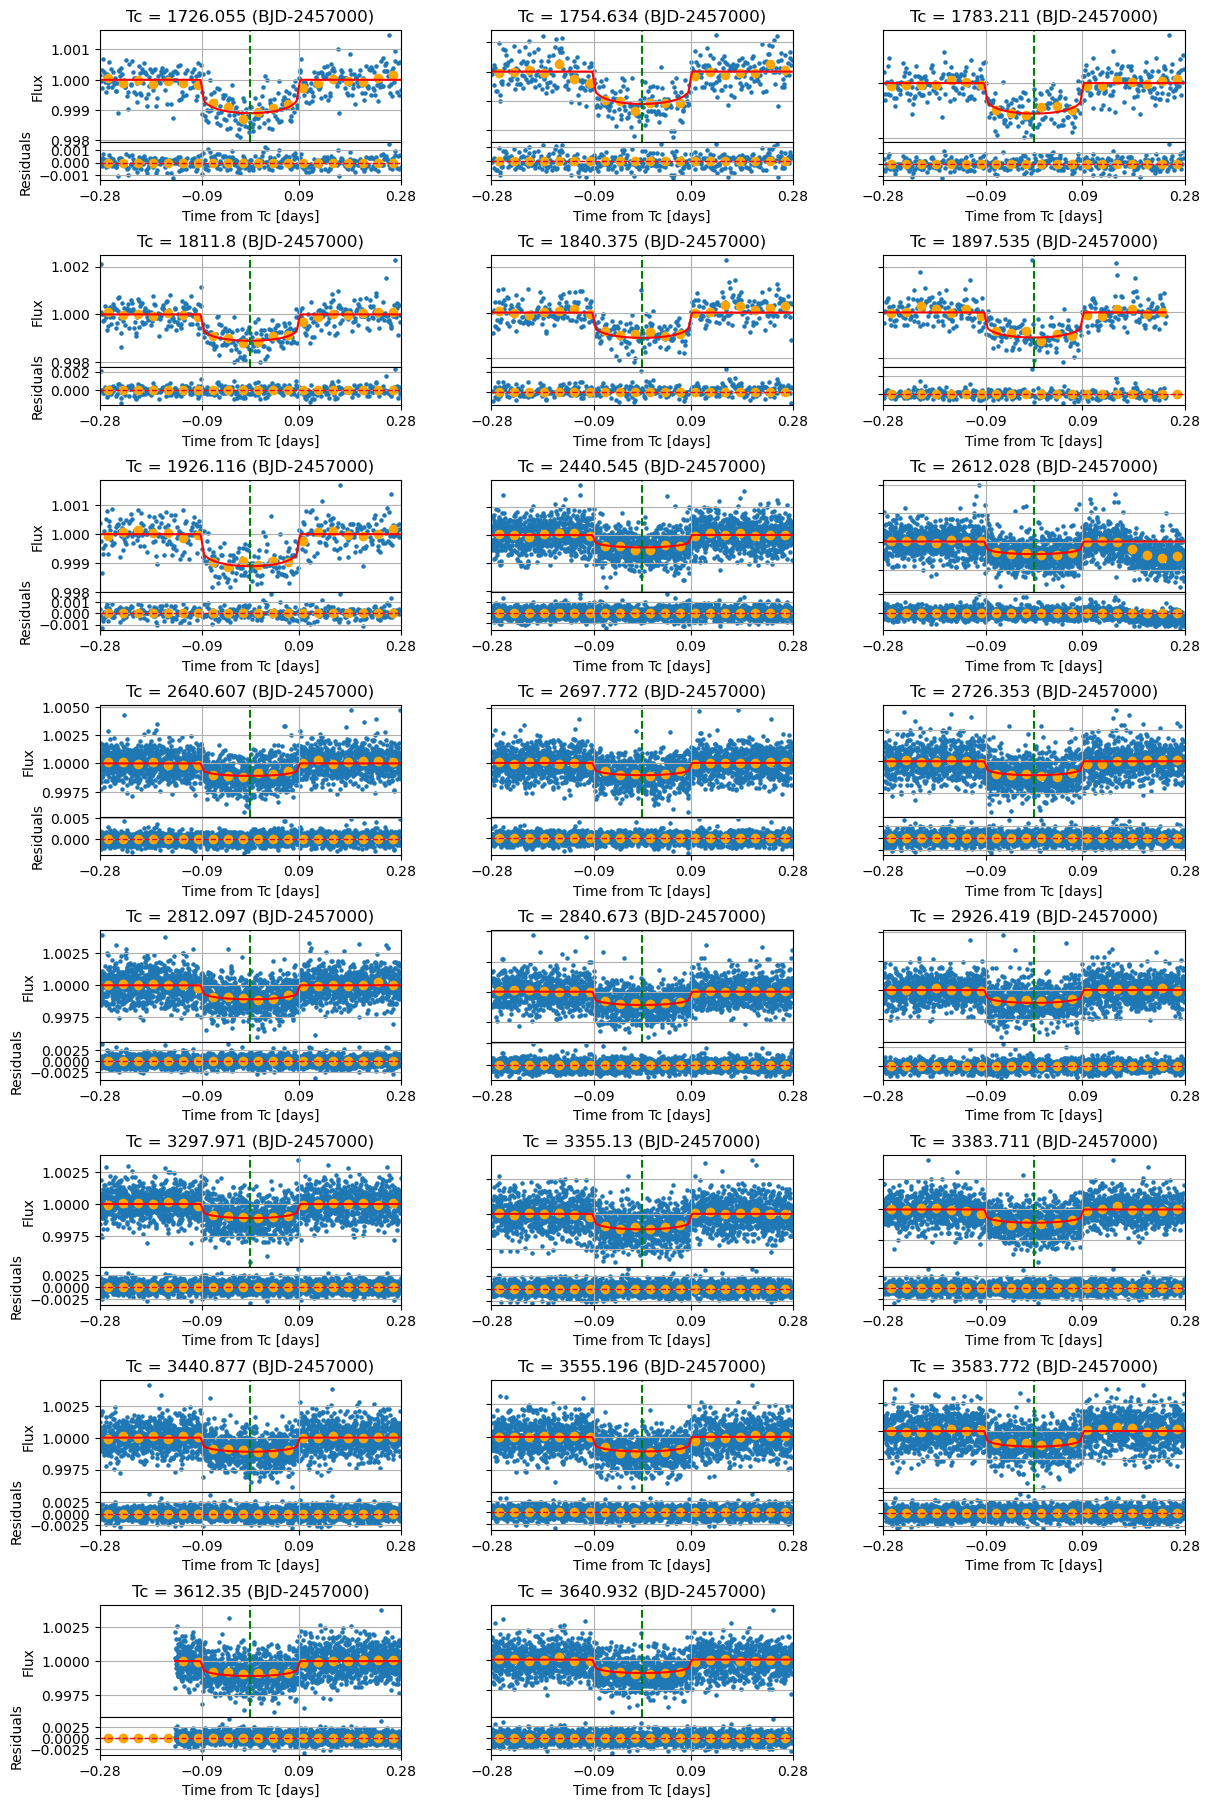

In [65]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

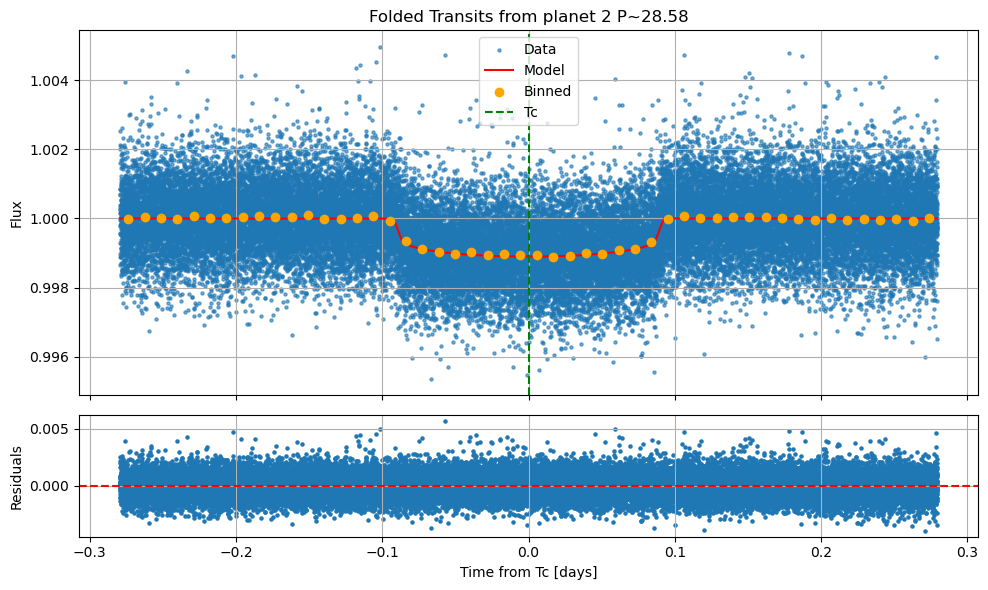

In [66]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## PLanet 3

In [67]:
### Planet params (from barros et al 2022)
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [68]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [69]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []
err_tc_chi = []

In [70]:
tc_chi_3, ttv_3, tc_err3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [71]:
print(tc_chi_3)

[1743.55283281 1781.90323028 1820.26542279 1896.96127611 1973.66389551
 2433.91718771 2625.67300259 2664.02492611 2702.35263997 2740.71772493
 2817.41035365 2932.46249122 3354.3037884  3392.66102082 3469.36024482
 3546.07312725 3584.39967719 3622.77016853 3661.12722679]


In [72]:
### after inspection of single transits
values_to_remove_3 = [3469.35398856, 3584.39976061]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []
tc_err_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])
        tc_err_3_cleaned.append(tc_err3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned
tc_err3 = tc_err_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [1743.55283280888, 1781.9032302831786, 1820.2654227892929, 1896.9612761051294, 1973.6638955051708, 2433.917187710397, 2625.673002591125, 2664.0249261065205, 2702.352639969187, 2740.7177249328274, 2817.410353648143, 2932.462491219806, 3354.3037884045525, 3392.6610208230263, 3546.073127250395, 3622.7701685262746, 3661.127226788756]


In [73]:
tc_err_3 = []
for i in range(len(tc_err3)):
    if len(tc_err3[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
        tc_err_3.append(sig)
    else:
        print(f"Unexpected format in tc_err3[{i}]: {tc_err3[i]}, {tc_chi_3[i]}")

# print(tc_err_3)

In [74]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

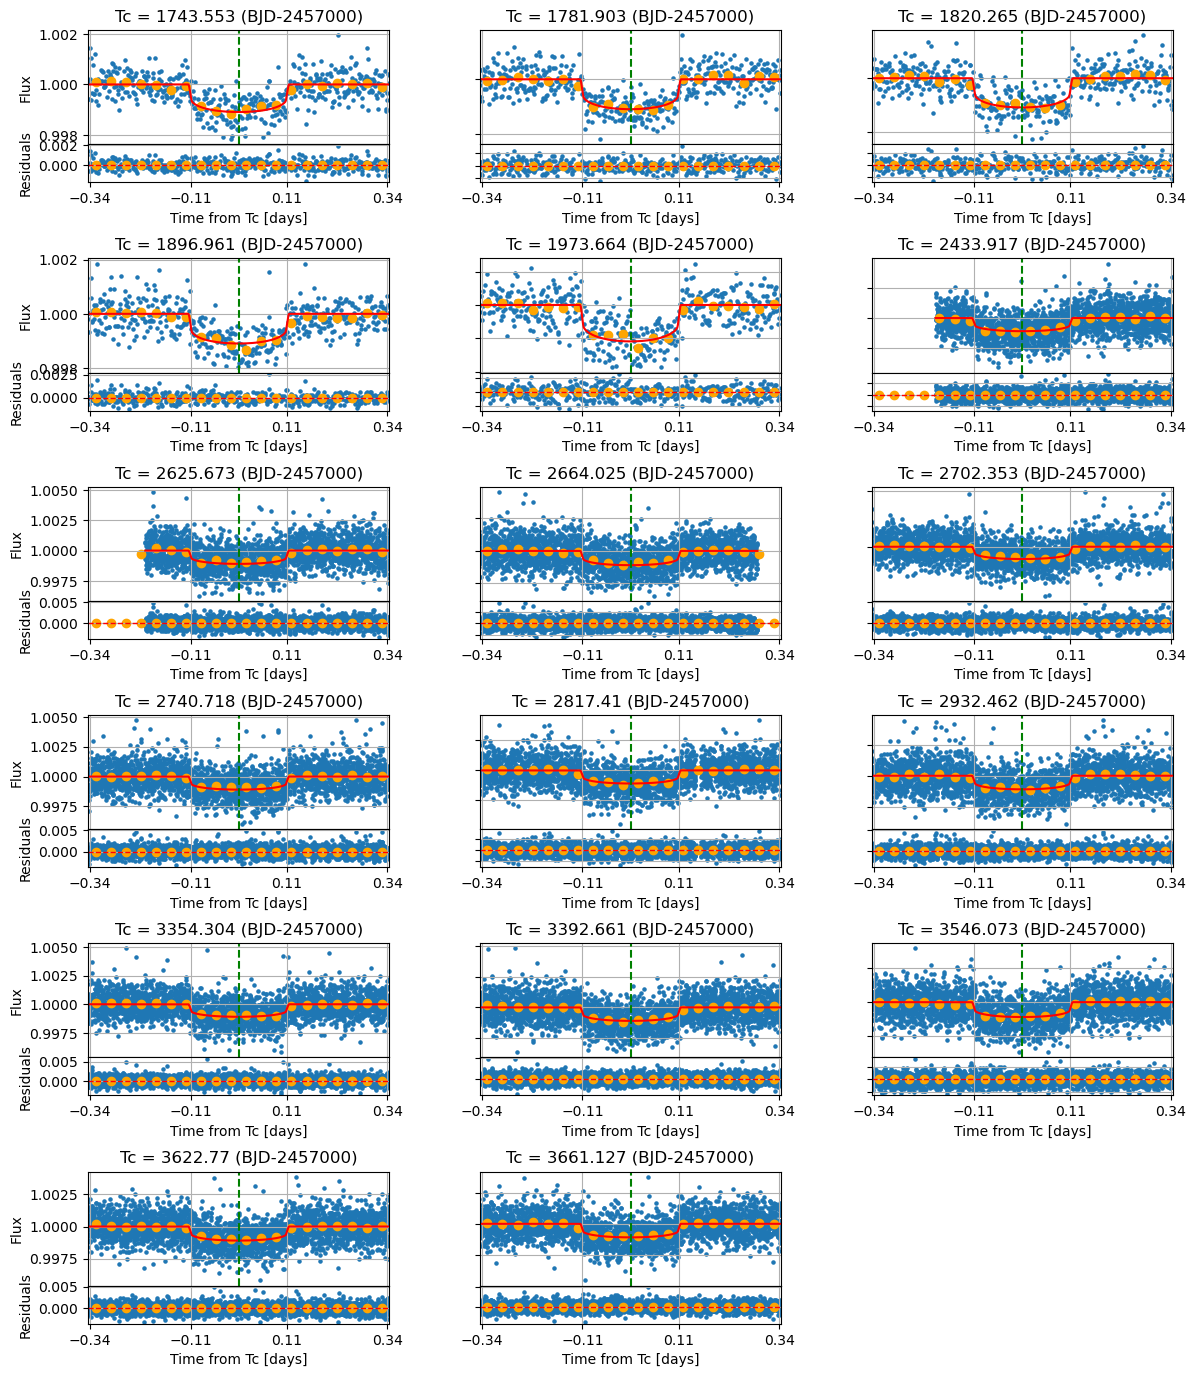

In [75]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

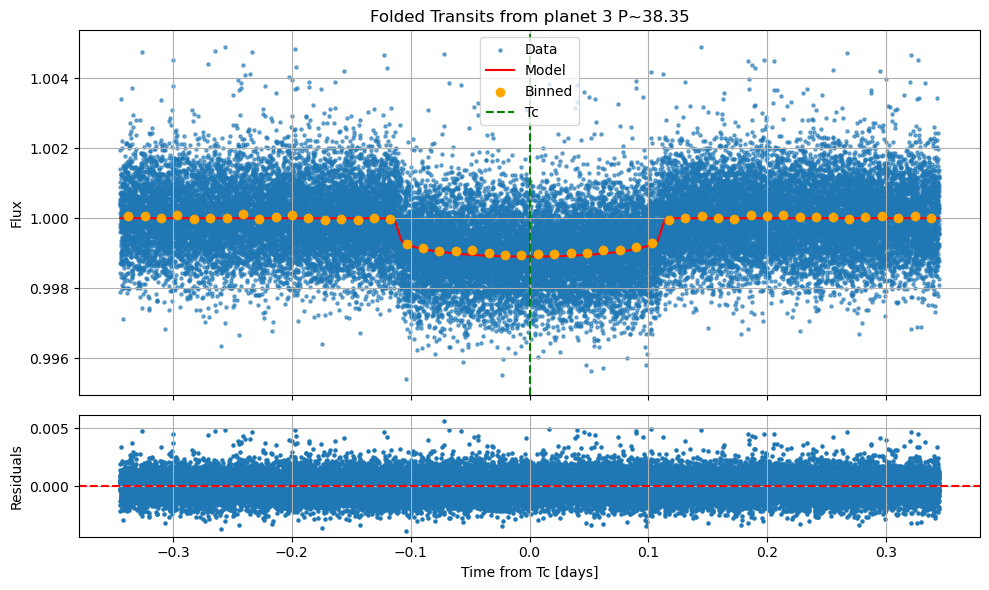

In [76]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

In [77]:
# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0.value) / planet_1_period.value).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0.value) / planet_2_period.value).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0.value) / planet_3_period.value).astype(int)


## Save data

In [96]:
print(len(transit_times_2))
print(len(transit_times_3))

23
17


In [97]:
print(planet_1_period.value)
print(planet_2_period.value)
print(planet_3_period.value)
print(planet_1_t0.value)
print(planet_2_t0.value)
print(planet_3_t0.value)
print(transit_times_2)
print(transit_times_3)
print(tc_err_1)
print(tc_err_2)
print(tc_err_3)
transit_times_2 = np.array(transit_times_2)
transit_times_3 = np.array(transit_times_3)

# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0.value) / planet_1_period.value).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0.value) / planet_2_period.value).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0.value) / planet_3_period.value).astype(int)

print("Indices of transits for planet 1:", indices_1)
print("Indices of transits for planet 2:", indices_2)
print("Indices of transits for planet 3:", indices_3)


8.880088008800879
28.579657965796578
38.35013501350135
1715.3907737341071
1726.070773734107
1743.605773734107
[1726.05497471 1754.63404397 1783.21147862 1811.79970925 1840.37532531
 1897.53491287 1926.11611318 2440.54520822 2612.0281482  2640.60685756
 2697.77150694 2726.35289967 2812.09680375 2840.67308347 2926.41909617
 3297.97103541 3355.12979823 3383.71060541 3440.87662011 3555.19563725
 3583.77180949 3612.34968722 3640.93152183]
[1743.55283281 1781.90323028 1820.26542279 1896.96127611 1973.66389551
 2433.91718771 2625.67300259 2664.02492611 2702.35263997 2740.71772493
 2817.41035365 2932.46249122 3354.3037884  3392.66102082 3546.07312725
 3622.77016853 3661.12722679]
[0.0011840522029804978, 0.0016816379648299487, 0.0016276921756886548, 0.0011344824809416019, 0.0014828056586015336, 0.0014673189970112967, 0.0024169978637177845, 0.002312459942675434, 0.0050628874881407755, 0.0013853356831597468, 0.0013711556817565856, 0.0011284668506440984, 0.0009809069327065963, 0.001131214118173921

In [98]:
### saving data for planets 2 and 3 (resonant pair)

planet_number = []
# for i in range(len(transit_times_1)):
#     planet_number.append(1)
for i in range(len(transit_times_2)):
    planet_number.append(2)
for i in range(len(transit_times_3)):
    planet_number.append(3)

all_transit_num = [] 
# for i in range(len(indices_1)):
#     all_transit_num.append(indices_1[i])
for i in range(len(indices_2)):
    all_transit_num.append(indices_2[i])
for i in range(len(indices_3)):
    all_transit_num.append(indices_3[i])

all_obs_tc = []
# for i in range(len(transit_times_1)):
#     all_obs_tc.append(transit_times_1[i])
for i in range(len(transit_times_2)):
    all_obs_tc.append(transit_times_2[i])
for i in range(len(transit_times_3)):
    all_obs_tc.append(transit_times_3[i])

all_obs_tc_err = []
# for i in range(len(tc_err_1)):
#     all_obs_tc_err.append(tc_err_1[i])
for i in range(len(tc_err_2)):
    all_obs_tc_err.append(tc_err_2[i])
for i in range(len(tc_err_3)):
    all_obs_tc_err.append(tc_err_3[i])



In [99]:
output_file = "toi_1339_transit_data_all.txt"
### save
data_to_save = np.column_stack((planet_number, all_transit_num, all_obs_tc, all_obs_tc_err))

### Define header
header = "Planet_num Index Tc Tc_err"

### Save to file
np.savetxt(output_file, data_to_save, fmt='%d %d %.8f %.8f', header=header, comments='')

print(f"Results saved to {output_file}")

Results saved to toi_1339_transit_data_all.txt


# O-C

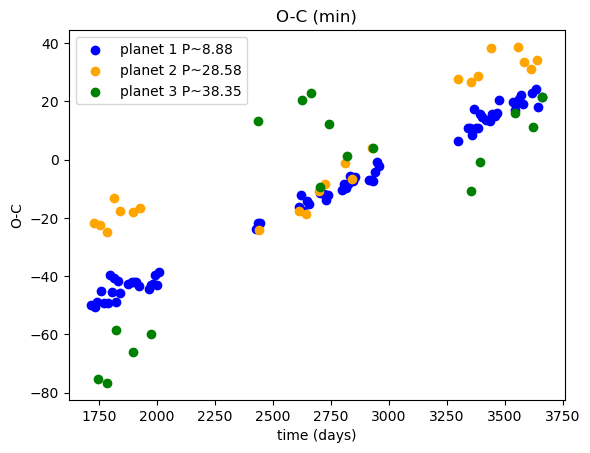

In [78]:
# TTV
ttv_1 = np.array(ttv_1)
ttv_2 = np.array(ttv_2)
ttv_3 = np.array(ttv_3)


plt.scatter(tc_chi_1, ttv_1*(24*60),c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

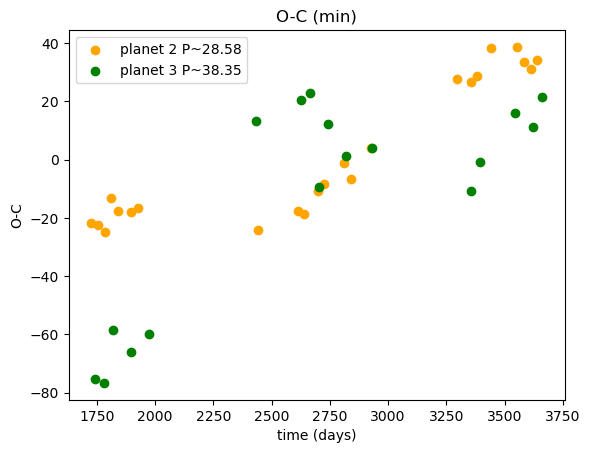

In [79]:
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

[-5.29610769e-03  6.50674184e-02 -6.50155043e+00  3.13930158e-04]
[ 9.74361740e-03  6.43154449e-02 -4.39111697e+00 -7.70771719e-04]


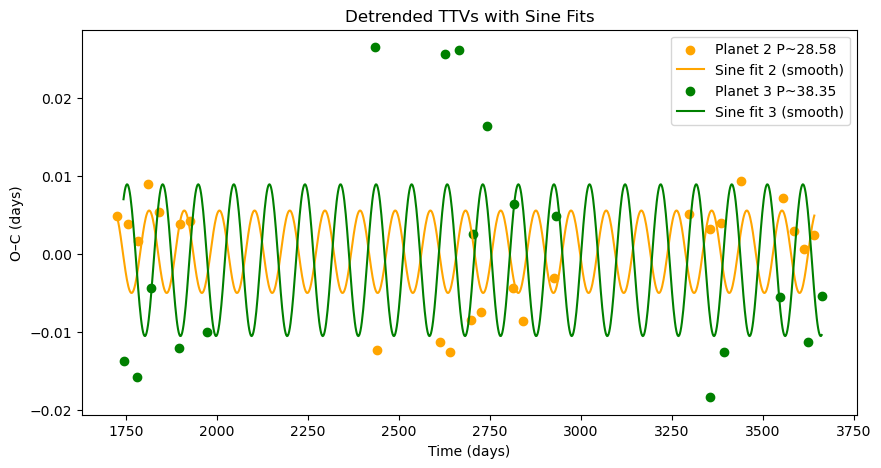

In [80]:
# Fit functions
def linear(x, a, b):
    return a * x + b

def sine(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset
# Fit and subtract for planet 2
popt_lin_2, _ = curve_fit(linear, tc_chi_2, ttv_2)
ttv_2_detrended = ttv_2 - linear(np.array(tc_chi_2), *popt_lin_2)

# Fit and subtract for planet 3
popt_lin_3, _ = curve_fit(linear, tc_chi_3, ttv_3)
ttv_3_detrended = ttv_3 - linear(np.array(tc_chi_3), *popt_lin_3)

# Initial guess: amplitude, frequency (rad/day), phase, offset
guess_2 = [0.01, 2 * np.pi / 100, 0, 0]
popt_sin_2, _ = curve_fit(sine, tc_chi_2, ttv_2_detrended, p0=guess_2)
print(popt_sin_2)

guess_3 = [0.03, 2 * np.pi / 100, 0, 0]
popt_sin_3, _ = curve_fit(sine, tc_chi_3, ttv_3_detrended, p0=guess_3)
print(popt_sin_3)

# Dense time arrays for smooth plots
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Detrended fits: only plot sine on linear-subtracted times
sine_fit_2 = sine(dense_time_2, *popt_sin_2)
sine_fit_3 = sine(dense_time_3, *popt_sin_3)

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended, color='orange', label=f'Planet 2 P~{round(planet_2_period.value, 3)}')
plt.plot(dense_time_2, sine_fit_2, 'orange', label='Sine fit 2 (smooth)')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended, color='green', label=f'Planet 3 P~{round(planet_3_period.value, 3)}')
plt.plot(dense_time_3, sine_fit_3, 'g', label='Sine fit 3 (smooth)')

plt.title('Detrended TTVs with Sine Fits')
plt.xlabel('Time (days)')
plt.ylabel('O–C (days)')
plt.legend()
plt.show()

[ 2.11373900e-05 -5.62823214e-02  3.46628450e-03  3.04058244e-02
  5.59999072e+00]
[ 3.18380686e-05 -9.38245579e-02  1.48559260e-02  3.05217332e-02
 -4.38713565e+00]


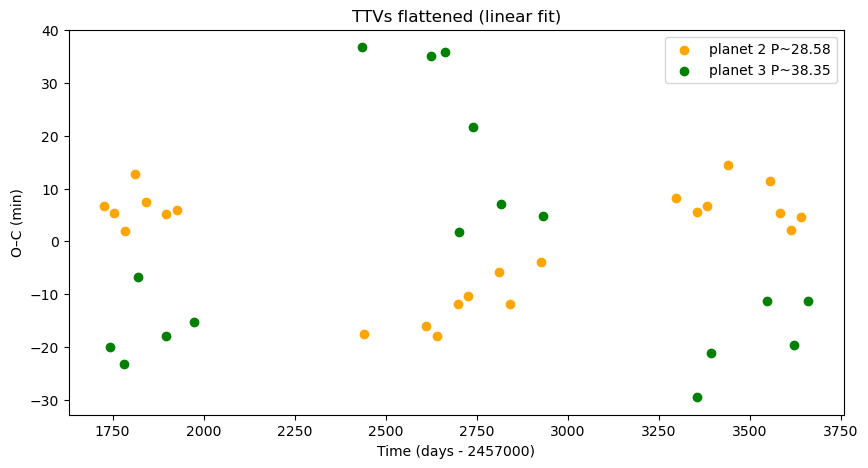

In [81]:
def linear_sine(t, a, b, A, omega, phase):
    return a * t + b + A * np.sin(omega * t + phase)

# Convert TTVs to minutes
ttv_2_min = np.array(ttv_2)
ttv_3_min = np.array(ttv_3) 

# Initial guesses: [slope, intercept, amplitude, omega, phase]
guess_2 = [28, 0, 0.01, 3.26255812e-02, 0]
guess_3 = [38, 0, 0.05, 3.05795071e-02, 0]

# Fit for planet 2
popt_2, _ = curve_fit(linear_sine, tc_chi_2, ttv_2_min, p0=guess_2)

# Fit for planet 3
popt_3, _ = curve_fit(linear_sine, tc_chi_3, ttv_3_min, p0=guess_3)

print(popt_2)
print(popt_3)

def linear_only(t, a, b):
    return a * t + b

ttv_2_detrended = ttv_2_min - linear_only(np.array(tc_chi_2), *popt_2[:2])
ttv_3_detrended = ttv_3_min - linear_only(np.array(tc_chi_3), *popt_3[:2])

# Dense time arrays for smooth curves
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Full model predictions
fit_2_full = linear_sine(dense_time_2, *popt_2)
fit_3_full = linear_sine(dense_time_3, *popt_3)

# Sine-only on detrended
fit_2_sine = fit_2_full - linear_only(dense_time_2, *popt_2[:2])
fit_3_sine = fit_3_full - linear_only(dense_time_3, *popt_3[:2])

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended*24*60, color='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
# plt.plot(dense_time_2, fit_2_sine, 'orange', label='Sine fit 2')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended*24*60, color='green', label=f'planet 3 P~{round(planet_3_period.value,3)}')
# plt.plot(dense_time_3, fit_3_sine, 'g', label='Sine fit 3')

plt.title('TTVs flattened (linear fit)')
plt.xlabel(f'Time (days - {TESS_offset})')
plt.ylabel('O–C (min)')
plt.legend()
plt.show()

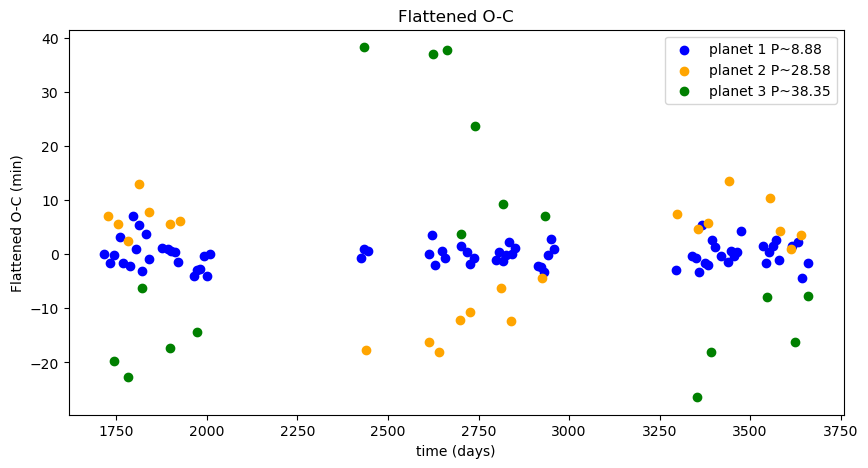

In [82]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3


plt.figure(figsize=(10, 5))
# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended,c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

## Multi-harmonic fit

In [83]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [84]:
j = 4 # 4:3 MMR
p_2 = planet_2_period.value
p_3 = planet_3_period.value
tc_2 = planet_2_t0.value
tc_3 = planet_3_t0.value


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006401171579743181
TTV period: 1497.7779667265215 days


In [85]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [86]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [87]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [88]:
print(len(indices_2))
print(len(transit_times_2))
print(len(tc_err_2))

23
23
23


In [89]:
from scipy.optimize import least_squares
indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)
indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)

### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72604644e+03  2.85803091e+01  8.20042240e-03  1.74357256e+03
  3.83512496e+01 -1.88290753e-02  1.61781717e+03  1.32422992e+03]


In [90]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [91]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04643998 ± 0.00071830
   P_b = 28.58030913 ± 0.00001705
  A_bc = 0.00820042 ± 0.00047637
  t_c0 = 1743.57256071 ± 0.00118623
   P_c = 38.35124957 ± 0.00004370
  A_cb = -0.01882908 ± 0.00070424
  P_cb = 1617.81717392 ± 42.37998709
 t_cb0 = 1324.22992418 ± 44.33434892


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_13292/3052238240.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


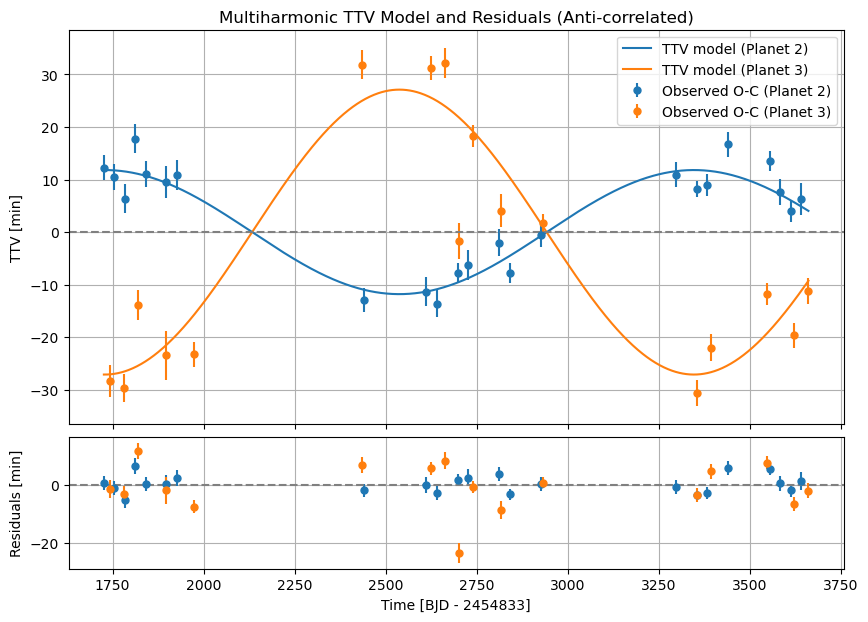

In [92]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) * 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) * 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [93]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1617.817174 ± 42.379987 days
A_23: 11.808000000000002 ± 0.68544 min
A_32: -27.11376 ± 1.01376 min


In [95]:
import pickle

# Bundle all relevant data into a dictionary
ttv_data = {
    "tc_lin_obs_2": t_lin_obs_b,
    "tc_lin_obs_3": t_lin_obs_c,
    "omc_2": oc_b,
    "omc_3": oc_c,
    "ttv_model_2": ttv_model_b,
    "ttv_model_3": ttv_model_c,
    "residuals_2": residuals_b,
    "residuals_3": residuals_c,
    "tc_err_2": np.array(tc_err_2),
    "tc_err_3": np.array(tc_err_3),
    "indices_2": np.array(indices_2),
    "indices_3": np.array(indices_3)
}

# Save to a file
with open("1339_data.pkl", "wb") as f:
    pickle.dump(ttv_data, f)
